# Vector Overlay

**Vector overlay operations** create new geometries by combining two input layers. They are fundamental GIS tools for answering questions like: *Where do these two areas overlap? What is in one area but not the other?*

**Topics covered in this module:**
- Five overlay operations: intersection, union, difference, symmetric difference, and identity
- Using the GeoPandas `.overlay()` method
- Comparing overlay results and understanding attribute behavior

## Learning Objectives

At the end of this module, you should be able to:
- Explain the difference between five vector overlay operations: intersection, union, difference, symmetric difference, and identity
- Use the GeoPandas `.overlay()` method to perform each operation
- Interpret the resulting geometries and attribute tables from overlay operations
- Understand how `.overlay()` differs from `.sjoin()` (overlay modifies geometries; sjoin does not)

In [1]:
# Turn off unwanted warnings
import warnings
warnings.filterwarnings("ignore")

## Vector overlay operations

Map overlay has been an important analytical tool for a very long time, as being able to combine and analyse multiple layers of spatial data together is crucial for various spatial planning processes, including e.g. suitability analyses, environment impact assessment, or land zoning. 

Overlay operations can be done both with vector and raster data. Vector overlay operations are commonly used to produce new geometries and associated attribute data based on two or more vector layers. When working with multiple spatial datasets (especially polygon or line layers), you might need to create new shapes based on places where the layers overlap (or do not overlap) with each other. Typical overlay operations include union, intersection, and difference (illustrated below). These are named after the result of the combination of two or more input layers which produce at least one (or more) output layer. Being able to combine spatial data layers is an important feature in GIS tools. These manipulations are often called set operations.

You would use overlay operations whenever you need to answer questions like: "Which parts of these land parcels fall within a flood zone?" or "What areas are covered by both park boundaries and city limits?" In short, overlay operations let you create new geometries that reflect the spatial relationships between two layers.

The basic idea of vector overlay operations is demonstrated below where green areas represent the result after the overlay operation. It is good to keep in mind that overlays operate at the GeoDataFrame level, not on individual geometries, and the properties from both are retained. In effect, for every shape in the left GeoDataFrame, this operation is executed against every other shape in the right GeoDataFrame.

<img src="img/vector_overlay_processes.png" width="600">

**Figure**. Typical vector overlay operations between two geographic layers (circle and rectangles).


To demonstrate how these overlay operations work in practice, we will carry out vector overlay operations between two Polygon datasets that represent i) the postal code areas in Washington DC and ii) a 5 km buffer around the Metro Center station. Let's start by reading the datasets and prepare them for analysis:

In [2]:
import geopandas as gpd

postal_areas = gpd.read_file("data/DC_Zip_Codes.zip")
# Only keep the columns we need
postal_areas = postal_areas[['NAME','LABEL','ZIP_CODE_T','GIS_ID','SHAPE_Leng','SHAPE_Area','geometry']]

metro_center = gpd.read_file("data/metro_center.gpkg")

# Check the data
postal_areas.head(5)

,NAME,LABEL,ZIP_CODE_T,GIS_ID,SHAPE_Leng,SHAPE_Area,geometry
0,NAVAL RESEARCH LABRATORY,20375,20375,ZIP_375,4422.676711,816514.286052,"POLYGON ((-8574430.308 4697130.048, -8574423.3..."
1,NAVAL SEA SYSTEMS COMMAND,20376,20376,ZIP_376,1539.274145,66833.191041,"MULTIPOLYGON (((-8571391.858 4703769.880, -857..."
2,NAVY CRIMINAL INVESTIGATIVE SERVICE,20388,20388,ZIP_388,445.868121,11505.664223,"POLYGON ((-8571108.153 4703584.840, -8571107.3..."
3,WASHINGTON NAVY YARD,20390,20390,ZIP_390,850.894380,18340.795837,"POLYGON ((-8570906.592 4704535.603, -8570906.3..."
4,NaN,20223,20223,ZIP_223,1781.623272,61384.345783,"MULTIPOLYGON (((-8573140.321 4700266.570, -857..."


In [3]:
postal_areas.shape

(172, 7)

In [4]:
metro_center.head()

,NAME,ADDRESS,LINE,GIS_ID,geometry
0,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,POINT (-8574726.674 4707117.556)


We can see that the `postal_areas` include MultiPolygon geometries representing 172 postal code areas, whereas the `metro_center` represents a single `Point` for the Metro Center station. As vector overlay operation happens between two geographic datasets, it is necessary to ensure that they both share the same Coordinate Reference System. Hence, let's first check that the `.crs` are matching using the Python's `assert` statement that tests whether the condition is `True`. If the test fails, the `assert` will throw an `AssertionError` with the message that we provide as text like in the following:

**Note on `assert`:** The `assert` statement is a simple debugging tool built into Python. It checks whether a condition is `True`. If the condition is `True`, nothing happens and the program continues. If the condition is `False`, Python raises an `AssertionError` and displays the message you provide. Here, we use it as a quick check to make sure our two datasets share the same CRS before proceeding.

In [5]:
assert postal_areas.crs == metro_center.crs, "The CRS does not match!"

Great, the CRS matches between the layers. Hence, let's continue and create a 5 km buffer around the Metro Center station which we will use in vector overlay operations:

In [6]:
station_buffer = metro_center.copy()
station_buffer["geometry"] = station_buffer.buffer(5000)

Here, we first created a copy of the original GeoDataFrame and then used the `.buffer()` method to create a Polygon circle with 5 km radius. Note that we pass `5000` to `.buffer()` because the coordinate reference system (CRS) of this dataset uses **meters** as its linear unit. Therefore, `.buffer(5000)` creates a buffer with a radius of 5,000 meters, which equals 5 kilometers. Always check the units of your CRS before using `.buffer()` -- if your data were in a geographic CRS (degrees), passing `5000` would not produce a 5 km buffer. Let's visualize the data on a map so that we can get a better understanding of the two layers and how they overlap with each other:

In [7]:
m = postal_areas.explore(tiles="CartoDB Positron", max_zoom=16)
station_buffer.explore(m=m, color="red")

## Intersection

An **intersection** returns only the areas where both input layers overlap. It is the geometric equivalent of a logical AND: keep only what is in *both* layers. The resulting features inherit attributes from both input layers.

**Intersection** keeps only the areas where both layers overlap. Geometrically, the result contains only the portions of the first layer's features that fall within the second layer's features. Any part of either layer that does not overlap with the other is discarded.

We are now ready to conduct an overlay analysis between these layers. We will create a new layer-based postal code polygons that **intersect** with the station_buffer layer. We can use a method called `.overlay()` to conduct overlay analysis between the given GeoDataFrame (`postal_areas`) and a second GeoDataFrame (**station_buffer**). With parameter `how`, we can control how the overlay analysis is conducted. Possible values are `'intersection'`, `'union'`, `'symmetric_difference'`, `'difference'`, and `'identity'`. 

Let's start by doing an overlay using `"intersection"` as the overlay operation:

In [8]:
# Intersection
intersection = postal_areas.overlay(station_buffer, how="intersection")
intersection

,NAME_1,LABEL,ZIP_CODE_T,GIS_ID_1,SHAPE_Leng,SHAPE_Area,NAME_2,ADDRESS,LINE,GIS_ID_2,geometry
0,NAVAL SEA SYSTEMS COMMAND,20376,20376,ZIP_376,1539.274145,66833.191041,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"MULTIPOLYGON (((-8571355.045 4703859.466, -857..."
1,NAVY CRIMINAL INVESTIGATIVE SERVICE,20388,20388,ZIP_388,445.868121,11505.664223,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"POLYGON ((-8571229.001 4703583.605, -8571189.3..."
2,WASHINGTON NAVY YARD,20390,20390,ZIP_390,850.894380,18340.795837,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"POLYGON ((-8570906.307 4704395.615, -8571041.7..."
3,NaN,20223,20223,ZIP_223,1781.623272,61384.345783,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"MULTIPOLYGON (((-8574442.200 4707264.278, -857..."
4,INTERNAL REVENUE SERVICE,20224,20224,ZIP_224,1009.983804,40762.213804,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"POLYGON ((-8574520.309 4706265.002, -8574700.3..."
...,...,...,...,...,...,...,...,...,...,...,...
148,SMITHSONIAN INSTITUTION,20560,20560,ZIP_560,1648.457806,73601.913324,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"MULTIPOLYGON (((-8574461.569 4705604.826, -857..."
149,NATIONAL GALLERY OF ART,20565,20565,ZIP_565,1872.441867,152128.056202,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"POLYGON ((-8573521.298 4706217.626, -8573425.3..."
150,JOHN F KENNEDY CENTER,20566,20566,ZIP_566,1038.379580,56448.786557,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"POLYGON ((-8577727.834 4706516.176, -8577845.2..."
151,NATIONAL LABOR RELATIONS BOARD,20570,20570,ZIP_570,45.284903,126.644246,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"POLYGON ((-8575109.452 4707828.703, -8575109.4..."


In [9]:
intersection.NAME_1.value_counts()

NAME_1
INTERNAL REVENUE SERVICE             6
US GOVERNMENT PRINTING OFFICE        3
FEDERAL AVIATION ADMINISTRATION      3
WASHINGTON NAVY YARD                 2
LIBRARY OF CONGRESS                  2
                                    ..
NATIONAL PRESS BUILDING              1
MARTIN LUTHER KING JR POST OFFICE    1
DEPARTMENT OF THE TREASURY           1
U.S. TAX COURT                       1
EXPORT IMPORT BANK                   1
Name: count, Length: 114, dtype: int64

In [10]:
intersection.shape

(153, 11)

As a result we got a new GeoDataFrame that includes 153 postal code areas (out of 172) that intersected with the `station_buffer`. As we can see, due to the overlay operation, the dataset contains the attributes from both input layers, i.e. it works in a bit similar manner as `sjoin()`. 


#### Quiz

Both `.overlay()` and `.sjoin()` combine two GeoDataFrames. In the intersection example, the result had 153 rows with attributes from both layers — similar to a spatial join. So what does `.overlay()` do that `.sjoin()` does not?

In [ ]:
# Use this cell to enter your solution.



To make it easier to understand how different vector overlay operations work, let's create an easy helper function called `plot_vector_overlay()` that creates a comparison map based on the results before and after the overlay operation. To do this, we use `matplotlib` library and create a subplot with 2 separate plots:

**Note:** You do not need to memorize the plotting code in the function below. It is provided as a utility so we can quickly visualize the results of each overlay operation. Focus on understanding what the overlay operations themselves do, not the details of this plotting function.

In [11]:
import matplotlib.pyplot as plt

def plot_vector_overlay(gdf1, gdf2, result, title):
    """
    Creates two maps next to each other based on `gdf1`, `gdf2` and the
    `result` GeoDataFrames.
    """

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))

    ax1 = gdf1.plot(ax=ax1)
    ax1 = gdf2.plot(ax=ax1, color="red", alpha=0.3)

    result.plot(ax=ax2)

    # Fetch bounds and apply to axis 2
    xmin, ymin, xmax, ymax = gdf1.total_bounds

    ax2.set_xlim(xmin, xmax)
    ax2.set_ylim(ymin, ymax)

    fig.suptitle(title, fontsize=16)
    
    # Add an arrow between the plots
    fig.text(0.49, 0.5, "⇨", fontsize=30, color="red")
    ax1.axis("off")
    ax2.axis("off")
    plt.tight_layout()
    return fig, ax1, ax2

Now we can call this function to create a visualization that demonstrates how the intersection overlay operations behaves:

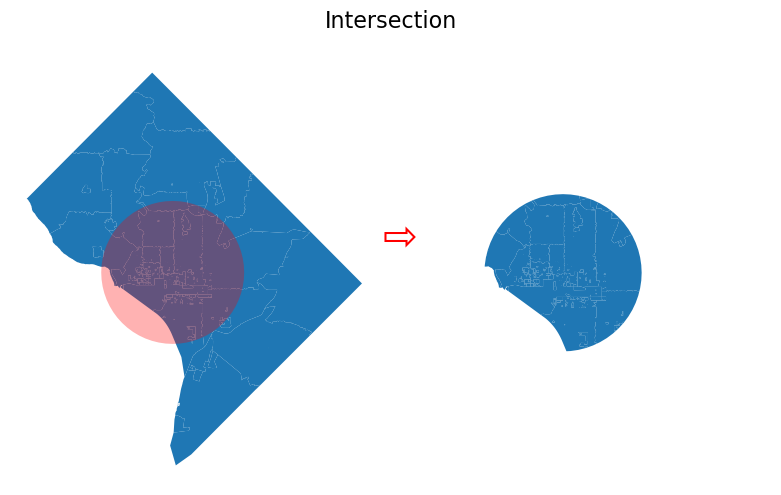

In [12]:
fig, ax1, ax2 = plot_vector_overlay(
    gdf1=postal_areas, gdf2=station_buffer, result=intersection, title="Intersection"
)

_**Figure**. Result after conducting vector overlay operation by intersecting the two layers._

As we can see, `"intersection"` overlay keeps the postal code areas that intersect with the circle and keeps all those geometries in the result. It is important to note that the intersecting GeoDataFrame (`station_buffer`) will modify the input geometries by cutting them in the border areas where they cross. 

This is one of the key differences between `.overlay()` and `.sjoin()`, as `.sjoin()` will not modify the input geometries. As mentioned earlier, attribute data from both GeoDataFrames are kept from the features. In the following, we will show one-by-one, how different overlay operations (i.e. union, difference, symmetric difference, identity) influence the results.

As a reminder, `.sjoin()` (spatial join) combines attribute data from two GeoDataFrames based on their spatial relationship (e.g., intersects, contains, within), but it keeps the original geometries unchanged. In contrast, `.overlay()` physically modifies the geometries by clipping them at the boundaries where the two layers meet.

## Union

A **union** combines the geometries from both input layers into a single output. It is the geometric equivalent of a logical OR: keep *everything* from both layers. Where the layers overlap, the overlapping area gets attributes from both; non-overlapping areas retain their original attributes (with NaN for the other layer's columns).

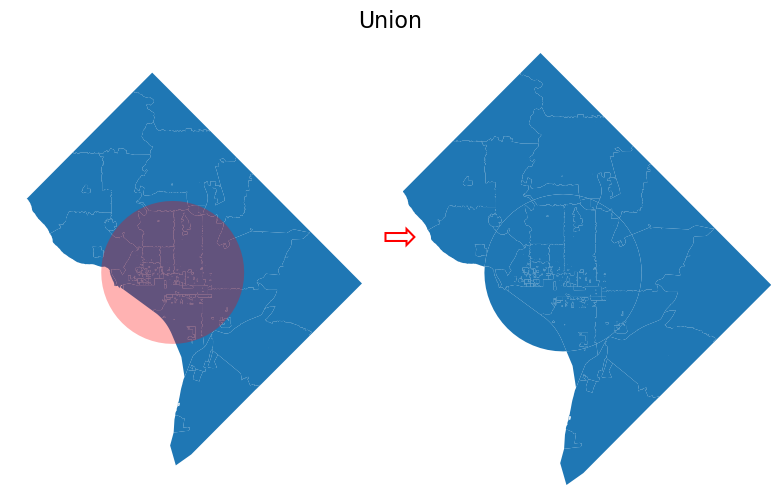

In [13]:
# Union
union = postal_areas.overlay(station_buffer, how="union")

fig, ax1, ax2 = plot_vector_overlay(
    gdf1=postal_areas, gdf2=station_buffer, result=union, title="Union"
)

_**Figure**. Result after conducting vector overlay operation based on union._

In [14]:
union.shape

(192, 11)

When using `"union"` overlay operation, the geometries from both GeoDataFrames are kept in the result. As you can see, the number of rows has increased from 172 to 192 rows. This happens because the postal code geometries are again modified by the `station_buffer` in the areas where the geometries cross each other: the postal code geometry is split into two areas where the buffer geometry crosses the postal code geometry. Hence, this will increase the number of rows in the final output. 

To understand this more concretely: imagine a single postal code polygon that the buffer circle cuts through the middle. That one polygon becomes **two** rows in the result -- one piece inside the buffer (which has attributes from both layers) and one piece outside the buffer (which only has postal code attributes, with NaN for the station columns). This splitting is why the total number of rows grows from 172 to 192.

#### Quiz

The original `postal_areas` had 172 rows. After `overlay(station_buffer, how="union")`, the result had 192 rows — even though we only added one buffer polygon. Where did the extra 20 rows come from?

In [ ]:
# Use this cell to enter your solution.


#### Quiz

Did you fully understand why the number of rows increase after doing the union overlay? If not, use the `.explore()` and investigate the geometries in areas where the postal code areas and the border of the buffer cross each other. When you hover over the border, what happens with the attribute values?

In [15]:
# Answer
print(
    """
When hovering over the buffer geometry border, the attribute values in the table change. 
Inside the ring, the attributes of the metro center station are kept in the results, whereas outside of the ring 
the table does not include data for the columns associated with the station.
"""
)

# Solution
union.explore()


When hovering over the buffer geometry border, the attribute values in the table change. 
Inside the ring, the attributes of the metro center station are kept in the results, whereas outside of the ring 
the table does not include data for the columns associated with the station.



## Difference and symmetric difference

Sometimes it might be useful to extract geometries *outside* a given layer. This can be achieved by using the `.overlay()` with `"difference"` operator:

**Difference** keeps only the parts of the first layer that do **not** overlap with the second layer. Think of it as subtracting one layer from the other. The result contains only the portions of the first layer's geometries that fall outside the second layer. Only attributes from the first layer are retained.

**Symmetric difference** keeps the parts of both layers that do **not** overlap with each other. It is the opposite of intersection: everything that is in either layer, but not in both. The result includes areas unique to the first layer and areas unique to the second layer, but excludes the overlapping area.

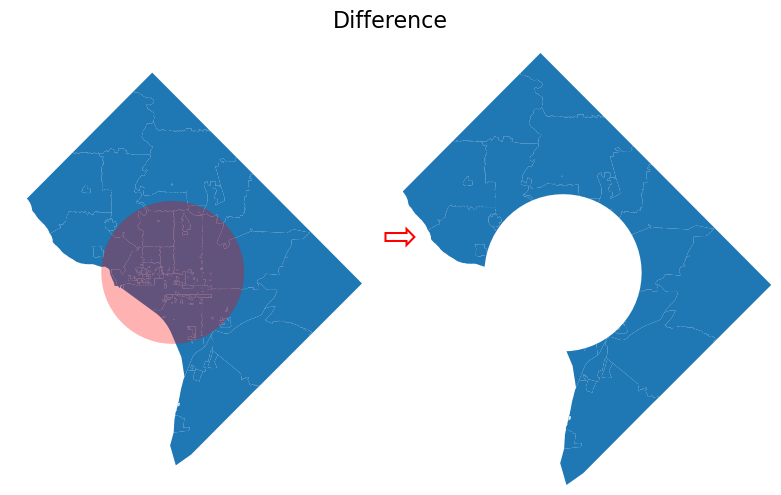

In [16]:
# Difference
difference = postal_areas.overlay(station_buffer, how="difference")

fig, ax1, ax2 = plot_vector_overlay(
    gdf1=postal_areas, gdf2=station_buffer, result=difference, title="Difference"
)

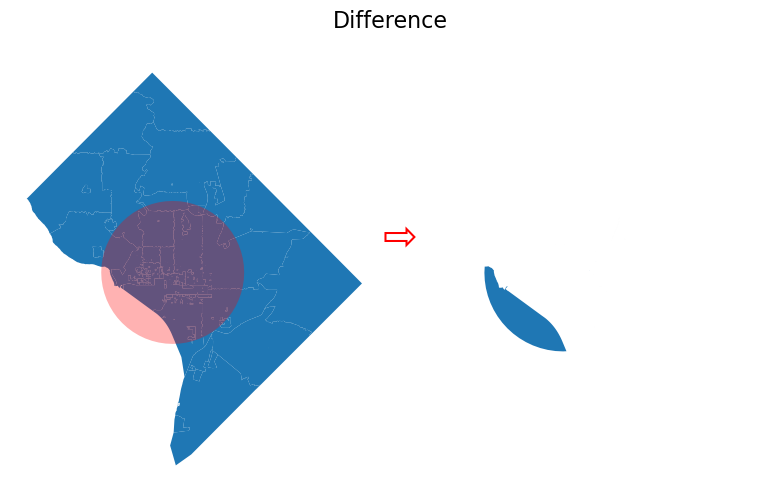

In [17]:
# Difference
difference = station_buffer.overlay(postal_areas, how="difference")

fig, ax1, ax2 = plot_vector_overlay(
    gdf1=postal_areas, gdf2=station_buffer, result=difference, title="Difference"
)

_**Figure**. Result after conducting vector overlay operation based on difference._

In [18]:
difference.columns.values

array(['NAME', 'ADDRESS', 'LINE', 'GIS_ID', 'geometry'], dtype=object)

In [19]:
difference.shape

(1, 5)

As can be seen from the results above, the `"difference"` will keep the postal code geometries that are outside of the buffer geometry.

Note we output **difference.columns.values** here to output only the column names. In terms of attributes, only the columns that are present in the source GeoDataFrame (i.e. `postal_areas`) are kept. 


#### Quiz

`postal_areas.overlay(station_buffer, how="difference")` and `station_buffer.overlay(postal_areas, how="difference")`, would these produce the same result? Why or why not?

In [ ]:
# Use this cell to enter your solution.


The symmetric difference overlay operation is an interesting one. It will keep the geometries and attributes outside of the `station_buffer` layer, as well as create a geometry that includes areas within the `station_buffer` ring but outside the `postal_areas` GeoDataFrame.

In other words, `"symmetric_difference"` removes the overlapping area and keeps everything else from both layers. If you think of intersection as "what is shared," then symmetric difference is "what is NOT shared." Notice in the figure that the area inside the buffer circle has been removed from the postal code areas, but a new geometry representing the parts of the buffer circle that fall outside the postal code areas is added. The last row of the result (row 38) contains this geometry with the station attributes, while all other rows contain postal code areas outside the buffer.

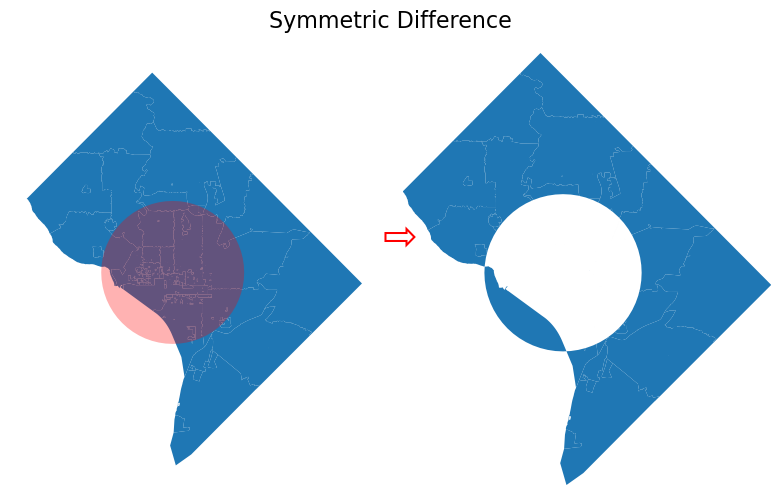

In [20]:
# Symmetric Difference
symmetric_difference = postal_areas.overlay(station_buffer, how="symmetric_difference")

fig, ax1, ax2 = plot_vector_overlay(
    gdf1=postal_areas,
    gdf2=station_buffer,
    result=symmetric_difference,
    title="Symmetric Difference",
)

_**Figure**. Result after conducting vector overlay operation based on symmetric difference._

In [21]:
symmetric_difference.columns

Index(['NAME_1', 'LABEL', 'ZIP_CODE_T', 'GIS_ID_1', 'SHAPE_Leng', 'SHAPE_Area',
       'NAME_2', 'ADDRESS', 'LINE', 'GIS_ID_2', 'geometry'],
      dtype='object')

In [22]:
symmetric_difference.shape

(39, 11)

In [23]:
symmetric_difference.tail()

,NAME_1,LABEL,ZIP_CODE_T,GIS_ID_1,SHAPE_Leng,SHAPE_Area,NAME_2,ADDRESS,LINE,GIS_ID_2,geometry
34,VETERANS HOSPITAL,20422.0,20422,ZIP_422,2317.996396,272020.343905,NaN,NaN,NaN,NaN,"POLYGON ((-8572379.469 4711818.894, -8572385.4..."
35,EXECUTIVE OFFICE OF THE PRESIDENT,20509.0,20509,ZIP_509,722.335264,23496.370963,NaN,NaN,NaN,NaN,"POLYGON ((-8573346.938 4700396.134, -8573476.4..."
36,DEPARTMENT OF HOMELAND SECURITY,20528.0,20528,ZIP_528,2193.184203,222279.472993,NaN,NaN,NaN,NaN,"POLYGON ((-8580476.131 4712826.719, -8580486.2..."
37,LIBRARY OF CONGRESS - TAYLOR ST ANNEX,20542.0,20542,ZIP_542,388.579839,7997.427420,NaN,NaN,NaN,NaN,"POLYGON ((-8574733.520 4713214.761, -8574807.1..."
38,NaN,NaN,NaN,NaN,NaN,NaN,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"MULTIPOLYGON (((-8579141.435 4707290.941, -857..."


As seen from above, the table includes attributes from the `postal_areas` GeoDataFrame as well as attributes from `station_buffer` in the last row of the GeoDataFrame. 

## Identity

**Identity** is similar to union, but it only preserves the full extent of the first (input) layer. The overlapping area is split and receives attributes from both layers, just like union. However, parts of the second layer that fall outside the first layer are discarded. Think of it as: "keep everything from the first layer, and where the second layer overlaps, add its attributes too."

As a last overlay operation, we have the `"identity"` which computes a geometric intersection of the input features and identity features. The input features or portions thereof that overlap identity features will get the attributes of those identity features. The basic idea is very similar to `"union"` but in this case, the areas outside of `postal_areas` GeoDataFrame will not be filled with the `station_buffer` geometry as demonstrated below:

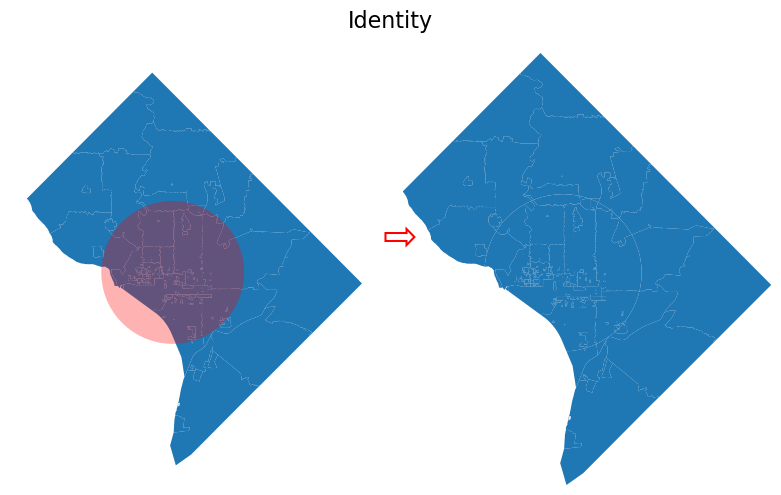

In [24]:
# Identity
identity = postal_areas.overlay(station_buffer, how="identity")

fig, ax1, ax2 = plot_vector_overlay(
    gdf1=postal_areas, gdf2=station_buffer, result=identity, title="Identity"
)

_**Figure**. Result after conducting vector overlay operation based on identity._

In [25]:
identity.columns

Index(['NAME_1', 'LABEL', 'ZIP_CODE_T', 'GIS_ID_1', 'SHAPE_Leng', 'SHAPE_Area',
       'NAME_2', 'ADDRESS', 'LINE', 'GIS_ID_2', 'geometry'],
      dtype='object')

In [26]:
identity.shape

(191, 11)

In [27]:
identity.tail()

,NAME_1,LABEL,ZIP_CODE_T,GIS_ID_1,SHAPE_Leng,SHAPE_Area,NAME_2,ADDRESS,LINE,GIS_ID_2,geometry
186,NaN,20032.0,20032,ZIP_032,30310.665262,2.192807e+07,NaN,NaN,NaN,NaN,"POLYGON ((-8572045.404 4701138.968, -8572263.8..."
187,VETERANS HOSPITAL,20422.0,20422,ZIP_422,2317.996396,2.720203e+05,NaN,NaN,NaN,NaN,"POLYGON ((-8572379.469 4711818.894, -8572385.4..."
188,EXECUTIVE OFFICE OF THE PRESIDENT,20509.0,20509,ZIP_509,722.335264,2.349637e+04,NaN,NaN,NaN,NaN,"POLYGON ((-8573346.938 4700396.134, -8573476.4..."
189,DEPARTMENT OF HOMELAND SECURITY,20528.0,20528,ZIP_528,2193.184203,2.222795e+05,NaN,NaN,NaN,NaN,"POLYGON ((-8580476.131 4712826.719, -8580486.2..."
190,LIBRARY OF CONGRESS - TAYLOR ST ANNEX,20542.0,20542,ZIP_542,388.579839,7.997427e+03,NaN,NaN,NaN,NaN,"POLYGON ((-8574733.520 4713214.761, -8574807.1..."


As can be seen from the results above, the output now includes attribute information from both GeoDataFrames, and the geometries in the `postal_areas` are split into multiple parts in places where the `station_buffer` cuts them. However, the geometry of the `station_buffer` itself is not included in the results (compared to `union` as seen below).

#### Quiz

Both union and identity split overlapping geometries and attach attributes from both layers. The union result had 192 rows; the identity result had 191 rows. What was excluded from identity, and in what real-world scenario would identity be the better choice?

In [ ]:
# Use this cell to enter your solution.



## Summary

The table below summarizes the five vector overlay operations and when to use each one:

| Operation | What it keeps | When to use it |
|---|---|---|
| **Intersection** | Only the overlapping areas from both layers | Find what is common between two layers (e.g., parcels within a flood zone) |
| **Union** | All areas from both layers (overlap + non-overlap) | Combine two layers completely, preserving everything from both |
| **Difference** | Areas from the first layer that do NOT overlap the second | Remove or exclude areas covered by another layer |
| **Symmetric Difference** | Areas from both layers that do NOT overlap each other | Find areas unique to each layer, excluding the shared zone |
| **Identity** | All areas from the first layer, with second layer attributes added where they overlap | Enrich the first layer with information from the second where they overlap |

**Key takeaways:**

- All five operations use the `.overlay()` method in GeoPandas, controlled by the `how` parameter.
- Overlay operations **modify geometries** by splitting them at boundaries where the two layers meet. This is the key difference from `.sjoin()`, which only joins attributes without changing shapes.
- The input layers must share the **same CRS** before performing any overlay operation.
- Attributes from both layers are carried through to the result where applicable. Rows that lack data from one layer will contain NaN values for that layer's columns.

In [28]:
union.tail()

,NAME_1,LABEL,ZIP_CODE_T,GIS_ID_1,SHAPE_Leng,SHAPE_Area,NAME_2,ADDRESS,LINE,GIS_ID_2,geometry
187,VETERANS HOSPITAL,20422.0,20422,ZIP_422,2317.996396,272020.343905,NaN,NaN,NaN,NaN,"POLYGON ((-8572379.469 4711818.894, -8572385.4..."
188,EXECUTIVE OFFICE OF THE PRESIDENT,20509.0,20509,ZIP_509,722.335264,23496.370963,NaN,NaN,NaN,NaN,"POLYGON ((-8573346.938 4700396.134, -8573476.4..."
189,DEPARTMENT OF HOMELAND SECURITY,20528.0,20528,ZIP_528,2193.184203,222279.472993,NaN,NaN,NaN,NaN,"POLYGON ((-8580476.131 4712826.719, -8580486.2..."
190,LIBRARY OF CONGRESS - TAYLOR ST ANNEX,20542.0,20542,ZIP_542,388.579839,7997.427420,NaN,NaN,NaN,NaN,"POLYGON ((-8574733.520 4713214.761, -8574807.1..."
191,NaN,NaN,NaN,NaN,NaN,NaN,Metro Center,"607 13TH STREET NW, WASHINGTON, DC","red, blue, orange, silver",MetroStnFullPt_27,"MULTIPOLYGON (((-8579141.435 4707290.941, -857..."
